In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving Electric_Vehicle_Population_Data.csv to Electric_Vehicle_Population_Data.csv


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,KM8K33AGXL,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258,0,43.0,249675142,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
1,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,1.0,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,14.0,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,5.307700e+10
3,5YJ3E1EA7J,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,45.0,104714466,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
4,WBY7Z8C5XJ,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97,0,22.0,185498386,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC,5.306701e+10


In [3]:
print(df.shape)
print("Range = 0:", round((df['Electric Range'] == 0).mean(), 3))
print("MSRP = 0:", round((df['Base MSRP'] == 0).mean(), 3))

pd.crosstab(
    df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'],
    df['Electric Range'] > 0
)

(150482, 17)
Range = 0: 0.463
MSRP = 0: 0.977


Electric Range,False,True
Clean Alternative Fuel Vehicle (CAFV) Eligibility,,
Clean Alternative Fuel Vehicle Eligible,0,62951
Eligibility unknown as battery range has not been researched,69698,0
Not eligible due to low battery range,0,17833


In [4]:
df['Electric Range'] = df['Electric Range'].replace(0, np.nan)
df['Base MSRP'] = df['Base MSRP'].replace(0, np.nan)

print("Range known:", round(df['Electric Range'].notna().mean(), 3))
print("MSRP known:", round(df['Base MSRP'].notna().mean(), 3))

Range known: 0.537
MSRP known: 0.023


In [5]:
# Cleaning text columns
df['Make'] = df['Make'].str.strip().str.upper()

# Vehicle age (2024 = year of the dataset snapshot)
df['Vehicle Age'] = 2024 - df['Model Year']

# Range category: unknown stays unknown
df['Range Category'] = pd.cut(
    df['Electric Range'],
    bins=[0, 100, 250, np.inf],
    labels=['Short', 'Mid', 'Long']
).astype(object).fillna('Unknown')

# Clear labels for the 3 eligibility categories
df['Eligibility'] = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].map({
    'Clean Alternative Fuel Vehicle Eligible': 'Eligible',
    'Not eligible due to low battery range': 'Not eligible (low range)',
    'Eligibility unknown as battery range has not been researched': 'Unknown'
})

print(df['Range Category'].value_counts())
print(df['Eligibility'].value_counts())

Range Category
Unknown    69698
Short      43502
Mid        28161
Long        9121
Name: count, dtype: int64
Eligibility
Unknown                     69698
Eligible                    62951
Not eligible (low range)    17833
Name: count, dtype: int64


In [6]:
# Share of vehicles with known range, by model year and EV type
coverage = (
    df.assign(known=df['Electric Range'].notna())
      .groupby(['Model Year', 'Electric Vehicle Type'])['known']
      .mean()
      .unstack()
      .round(2)
)
print(coverage.tail(10))

# Average known range by EV type
print(df.groupby('Electric Vehicle Type')['Electric Range'].agg(['count', 'mean', 'median']).round(1))

Electric Vehicle Type  Battery Electric Vehicle (BEV)  \
Model Year                                              
2015                                             1.00   
2016                                             1.00   
2017                                             1.00   
2018                                             1.00   
2019                                             1.00   
2020                                             0.99   
2021                                             0.03   
2022                                             0.00   
2023                                             0.00   
2024                                             0.00   

Electric Vehicle Type  Plug-in Hybrid Electric Vehicle (PHEV)  
Model Year                                                     
2015                                                      1.0  
2016                                                      1.0  
2017                                                      1

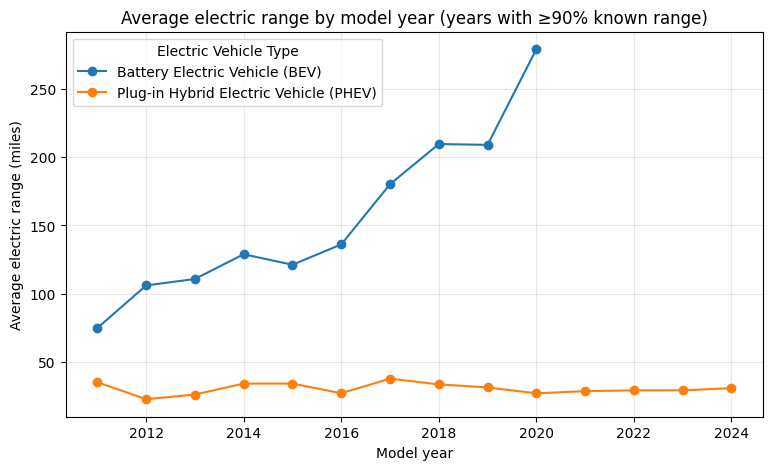

In [7]:
df['range_known'] = df['Electric Range'].notna()

cov = df.groupby(['Model Year', 'Electric Vehicle Type'])['range_known'].mean().unstack()
mean_range = (
    df[df['range_known'] & (df['Model Year'] >= 2011)]
      .groupby(['Model Year', 'Electric Vehicle Type'])['Electric Range']
      .mean().unstack()
)
mean_range = mean_range.where(cov >= 0.9)   # only years with at least 90% known range

mean_range.plot(marker='o', figsize=(9, 5))
plt.title('Average electric range by model year (years with ≥90% known range)')
plt.xlabel('Model year')
plt.ylabel('Average electric range (miles)')
plt.grid(alpha=0.3)
plt.show()

In [8]:
check = df[(df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)')
           & (df['Model Year'].isin([2018, 2019, 2020]))
           & df['range_known']]

print(check.groupby('Model Year').agg(vehicles=('Electric Range', 'count'),
                                      models=('Model', 'nunique'),
                                      avg_range=('Electric Range', 'mean')).round(1))

print(check[check['Model Year'] == 2020]['Model'].value_counts().head(8))

            vehicles  models  avg_range
Model Year                             
2018           10046      12      209.8
2019            8769      14      209.2
2020            9558      13      279.4
Model
MODEL 3    3750
MODEL Y    2278
BOLT EV     985
MODEL X     680
LEAF        611
NIRO        414
MODEL S     399
KONA        166
Name: count, dtype: int64


## Key finding: electric range over time

- Electric range is unknown (recorded as 0) for 46% of vehicles, so zeros were replaced with missing values.
- Range is known for almost all BEVs up to model year 2020 and for almost none from 2021 onward, so the BEV trend stops at 2020.
- Among BEVs, average known range rises from about 75 miles (2011) to about 210 miles (2018-2019) and about 279 miles (2020).
- The 2020 jump is partly a mix effect: Tesla Model 3 and Model Y make up about 63% of BEVs with a known range that year.
- PHEVs stay flat at about 30 miles throughout.
- Clean Fuel eligibility is defined by battery range, so comparing range between eligible and non-eligible vehicles is circular and was not used as a finding.

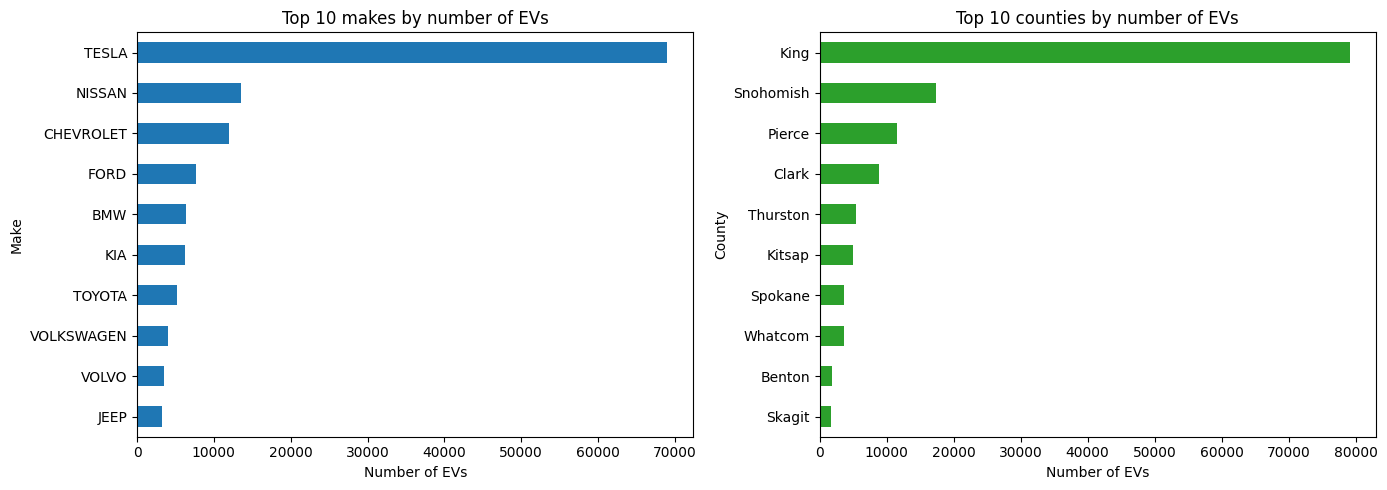

Make
TESLA        45.8
NISSAN        9.0
CHEVROLET     8.0
Name: proportion, dtype: float64
County
King    52.5
Name: proportion, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_makes = df['Make'].value_counts().head(10)
top_makes.sort_values().plot(kind='barh', ax=axes[0], color='#1f77b4')
axes[0].set_title('Top 10 makes by number of EVs')
axes[0].set_xlabel('Number of EVs')

top_counties = df['County'].value_counts().head(10)
top_counties.sort_values().plot(kind='barh', ax=axes[1], color='#2ca02c')
axes[1].set_title('Top 10 counties by number of EVs')
axes[1].set_xlabel('Number of EVs')

plt.tight_layout()
plt.show()

print((df['Make'].value_counts(normalize=True).head(3) * 100).round(1))
print((df['County'].value_counts(normalize=True).head(1) * 100).round(1))

In [10]:
from scipy.stats import ttest_ind

sub = df[(df['Model Year'].between(2011, 2020)) & df['range_known']]

bev = sub[sub['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']['Electric Range']
phev = sub[sub['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']['Electric Range']

res = ttest_ind(bev, phev, equal_var=False)
ci = res.confidence_interval()

print("BEV:  n =", len(bev), " mean =", round(bev.mean(), 1))
print("PHEV: n =", len(phev), " mean =", round(phev.mean(), 1))
print("Mean difference:", round(bev.mean() - phev.mean(), 1), "miles")
print("95% CI of difference:", round(ci.low, 1), "to", round(ci.high, 1))
print("p-value:", res.pvalue)

BEV:  n = 46548  mean = 194.9
PHEV: n = 19608  mean = 31.9
Mean difference: 163.0 miles
95% CI of difference: 162.3 to 163.8
p-value: 0.0


## Statistical comparison: BEV vs PHEV

Using vehicles from model years 2011-2020 (the years where range is known for both types), BEVs have an average electric range of about 195 miles versus about 32 miles for PHEVs, a difference of about 163 miles (95% CI: 162.3 to 163.8, Welch's t-test).

Notes:
- With tens of thousands of vehicles per group, the p-value is effectively zero, so the size of the difference matters more than significance.
- The result is expected from how the two vehicle types work; it quantifies the gap rather than discovering it.
- Each row is a registered vehicle, not a model, so the BEV average is weighted toward the most common models (mainly Tesla).
- An earlier comparison of Clean Fuel eligible vs not eligible vehicles was dropped, because eligibility is defined by battery range, which makes that comparison circular.

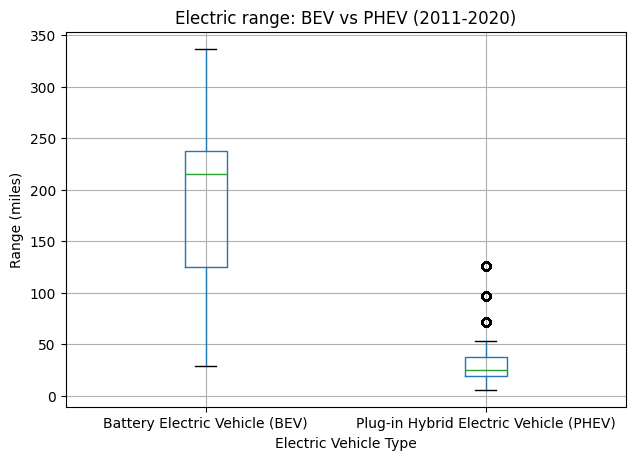

In [11]:
import matplotlib.pyplot as plt

sub = df[(df["Model Year"].between(2011, 2020)) & (df["Electric Range"] > 0)]

sub.boxplot(column="Electric Range", by="Electric Vehicle Type", figsize=(7, 5))
plt.title("Electric range: BEV vs PHEV (2011-2020)")
plt.suptitle("")
plt.ylabel("Range (miles)")
plt.show()

## Summary



- **Main finding:** Battery electric vehicles (BEVs) have a much higher electric range than plug-in hybrids (PHEVs): about 195 miles versus 32 miles on average for model years 2011-2020, a difference of about 163 miles (95% CI: 162.3 to 163.8, Welch's t-test).
- **Size over significance:** With tens of thousands of vehicles per group, the p-value is effectively zero, so the size of the gap matters more than its significance. The boxplot shows the two distributions barely overlap.
- **Limitation:** Each row is a registered vehicle, not a model, so the BEV average is weighted toward the most common models (mainly Tesla).
- **Data note:** Price information is missing for most vehicles in the dataset, so price was not used in this analysis.
- **Dropped analysis:** A comparison of Clean Fuel eligible vs. not eligible vehicles was removed, because eligibility is defined by battery range, which makes the comparison circular.